**CHURN - MODEL**

TAKS:
Sviluppare un modello predittivo in grado di identificare i clienti a più alto rischio di churn.

churn model steps:
- dataset loading
- EDA
- Data cleaning
- Train and Test Datasets
- Train XGBoost model on the training set
- Hyperparameter tuning of the model
- Evaluation of the model


**1. Dataset Loading**

In [19]:
# Importazione delle librerie principali
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, precision_score, roc_curve
import xgboost as xgb

# Impostazioni grafiche per le visualizzazioni
%matplotlib inline
sns.set(style='whitegrid')

# Caricamento del dataset
df = pd.read_csv('data.csv', sep=';')

# Controllo iniziale sul dataset
print("Shape:", df.shape)
df.head()
df.info()




Shape: (5630, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5628 non-null   float64
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5628 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  

**2. Exploratory Data Analysis (EDA)**

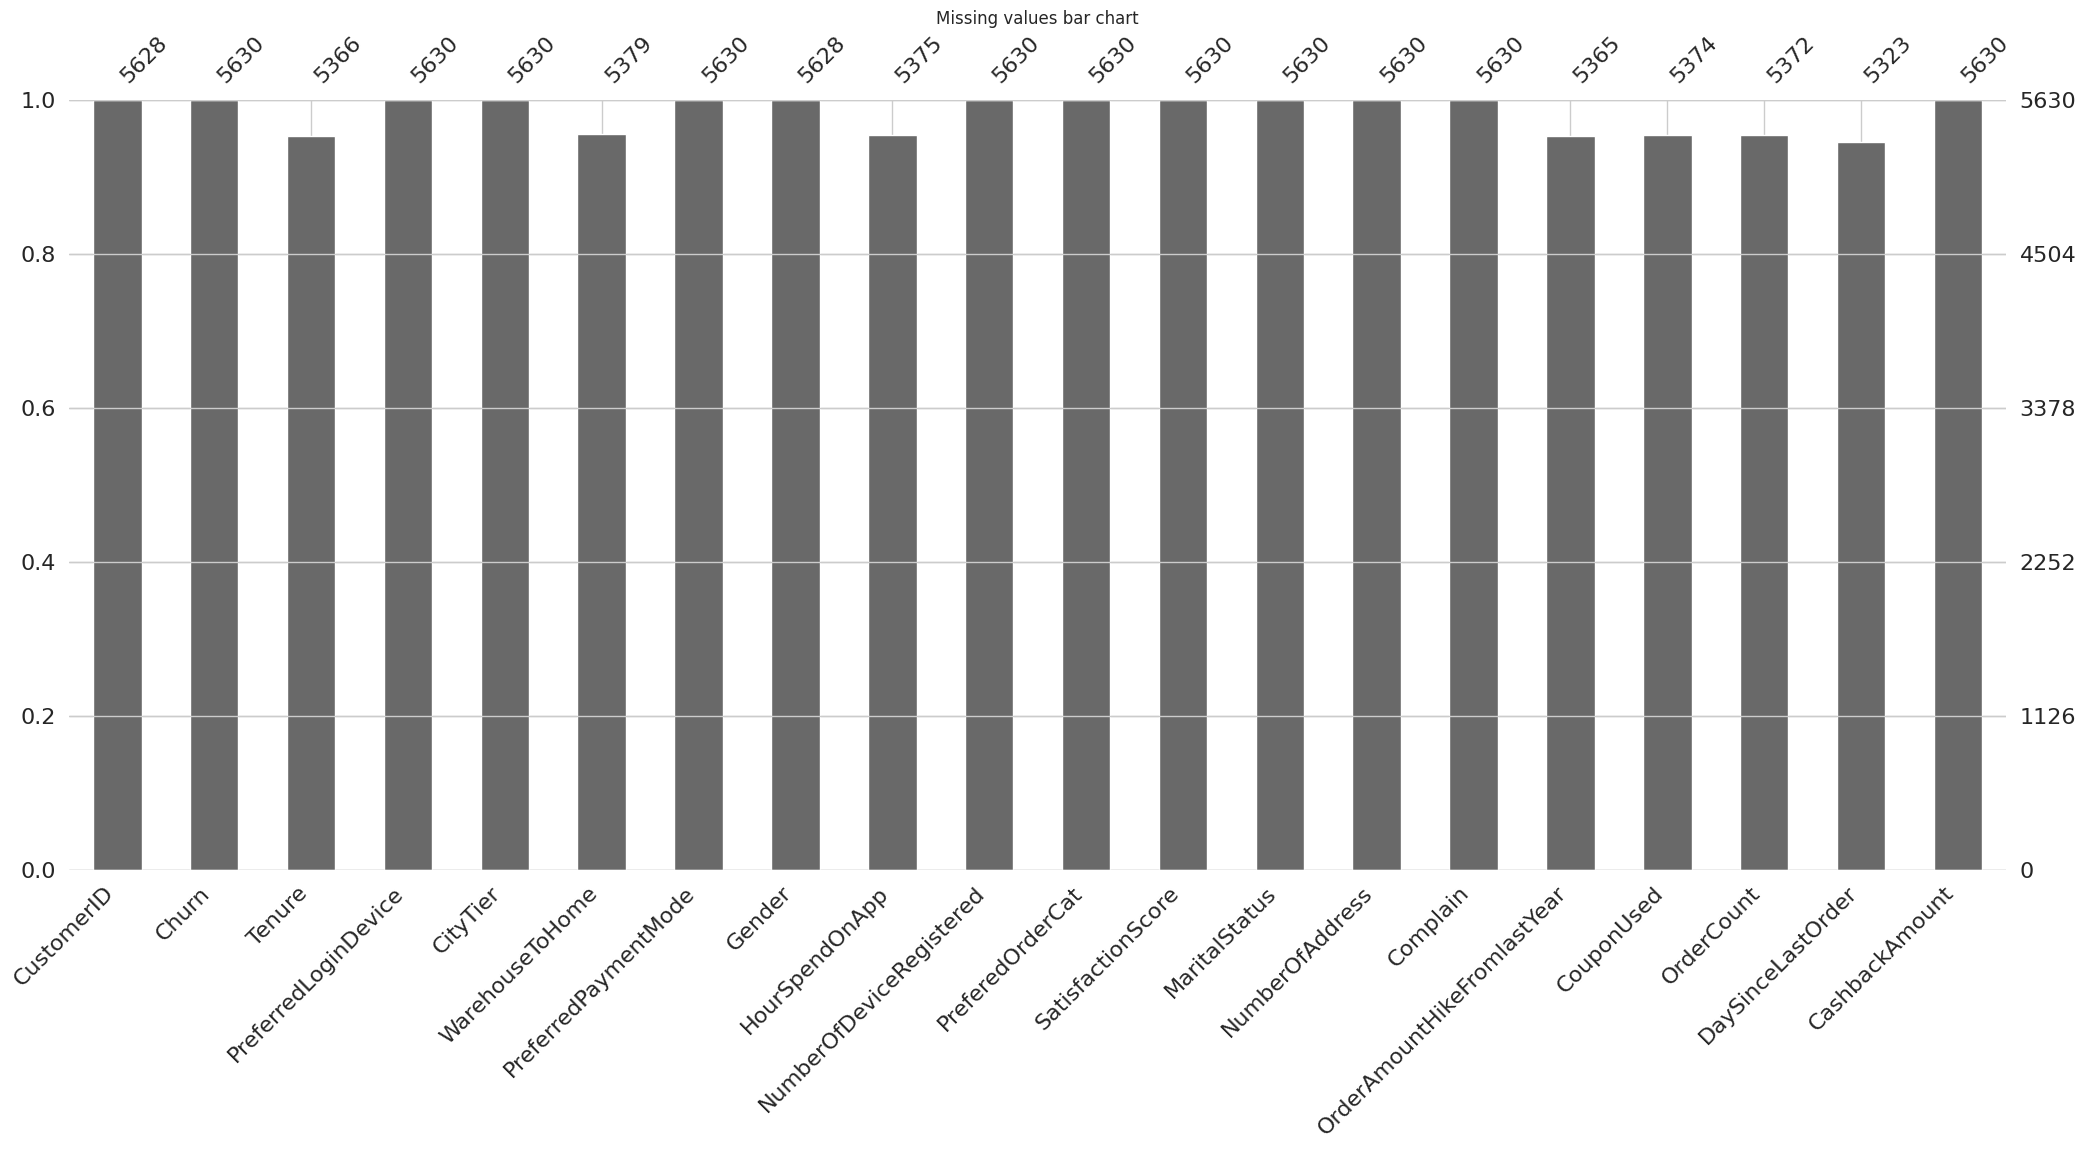

<Figure size 800x600 with 0 Axes>

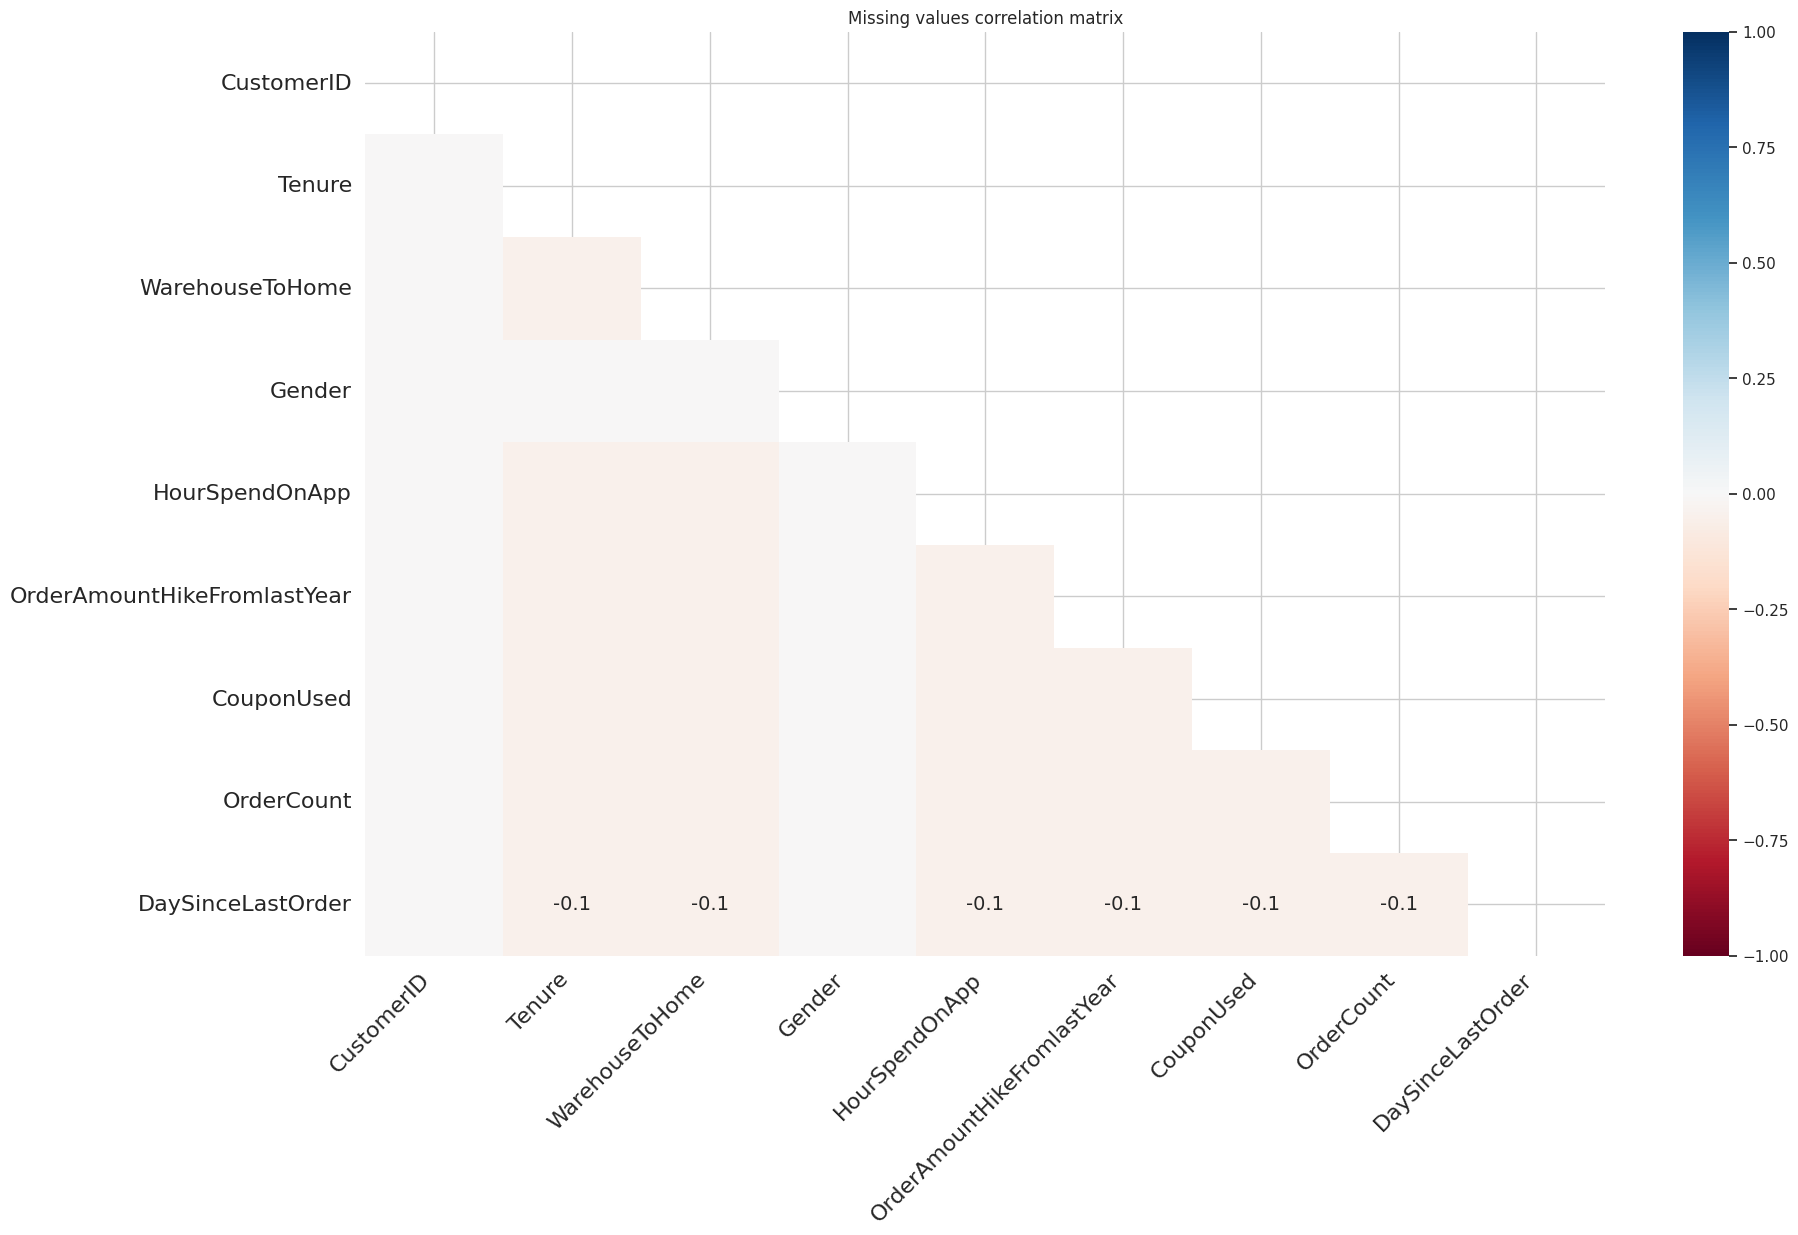

                             missing_count  missing_pct
CustomerID                               2         0.04
Tenure                                 264         4.69
WarehouseToHome                        251         4.46
Gender                                   2         0.04
HourSpendOnApp                         255         4.53
OrderAmountHikeFromlastYear            265         4.71
CouponUsed                             256         4.55
OrderCount                             258         4.58
DaySinceLastOrder                      307         5.45


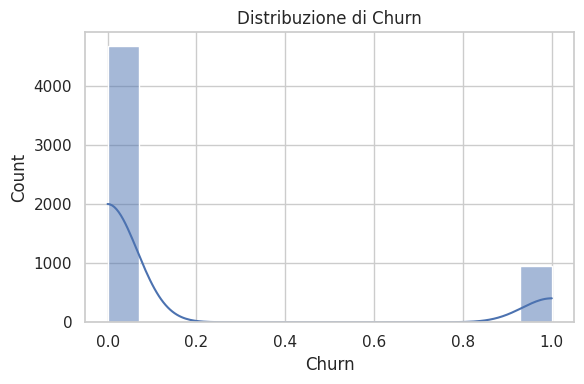

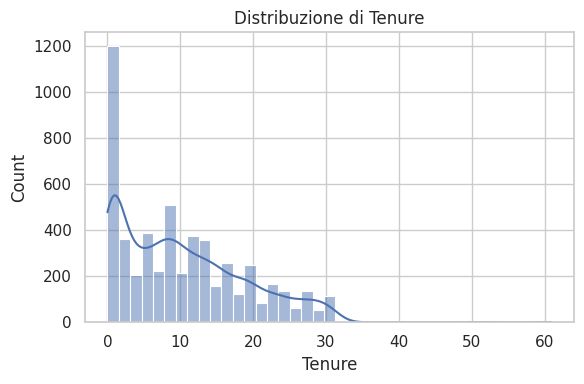

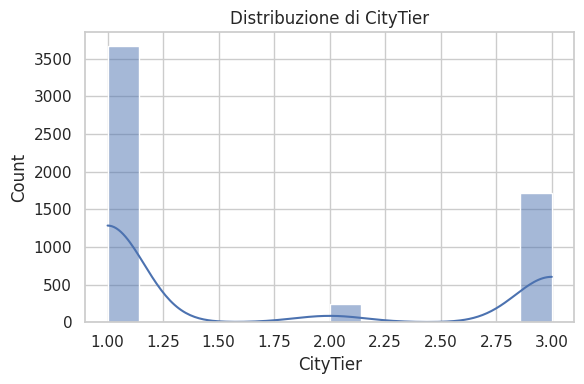

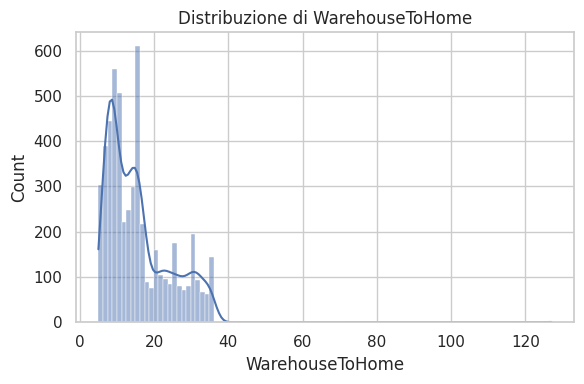

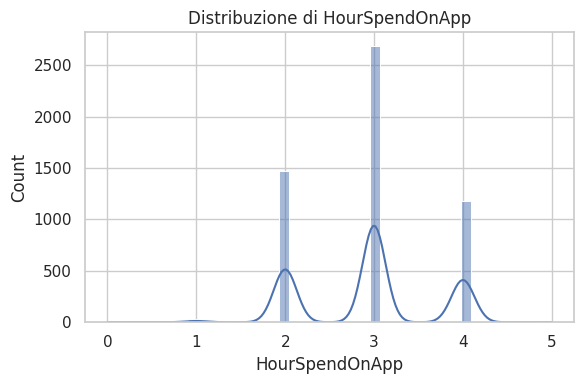

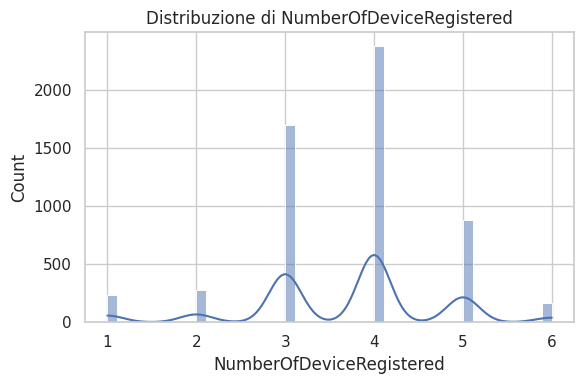

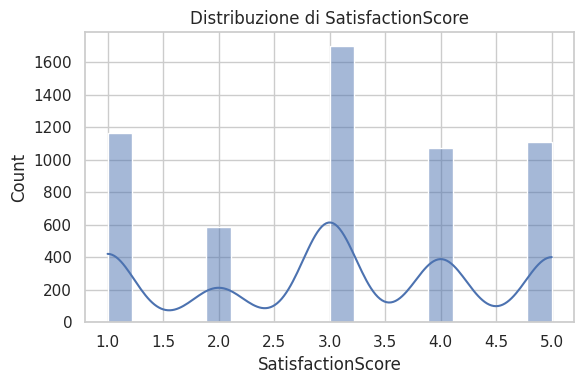

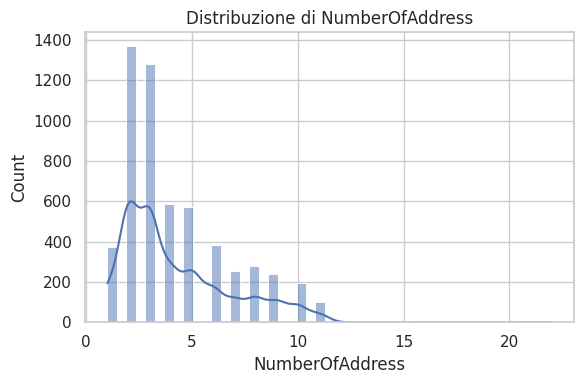

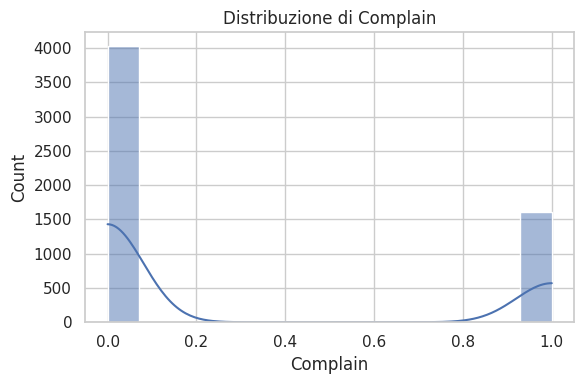

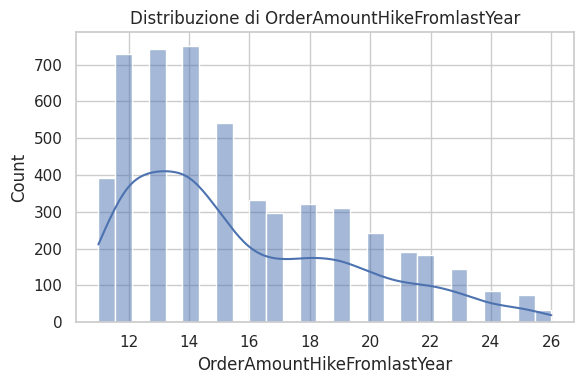

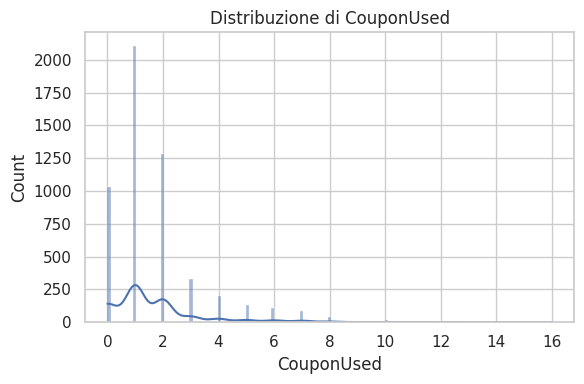

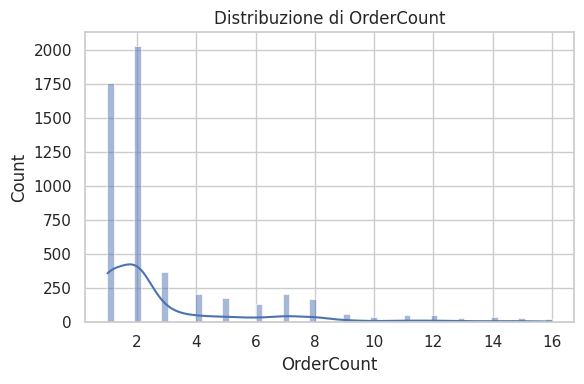

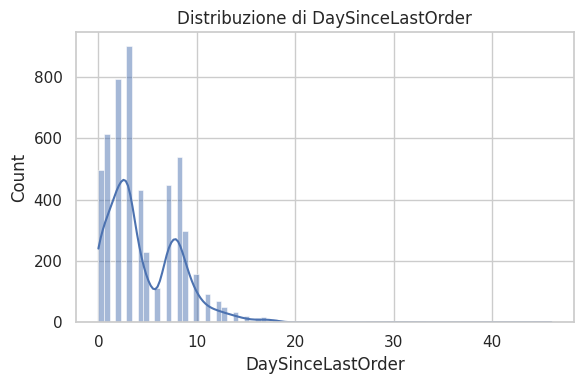

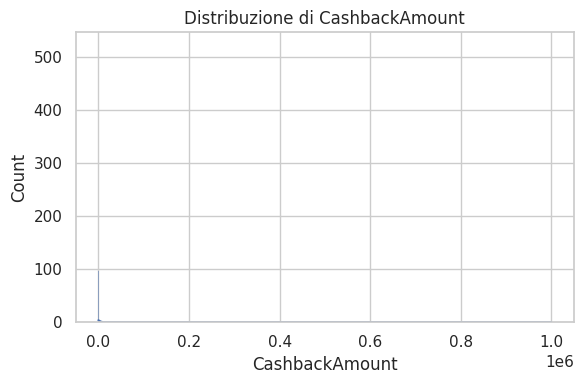

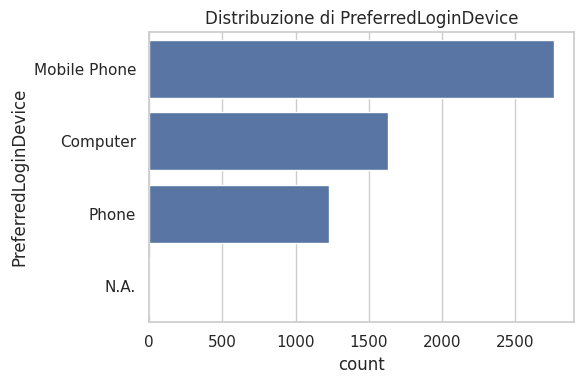

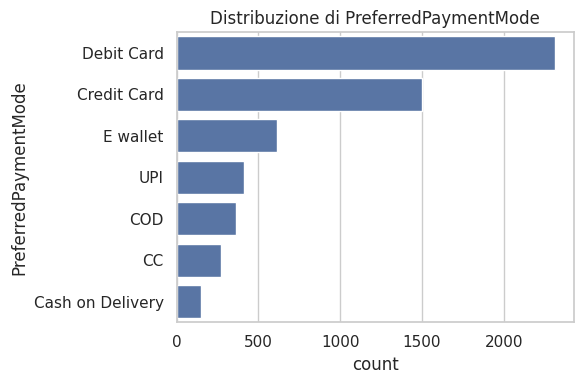

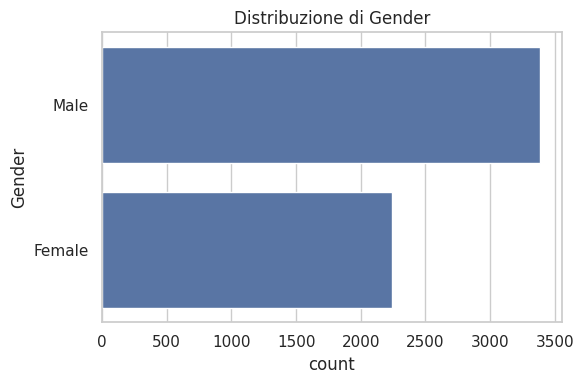

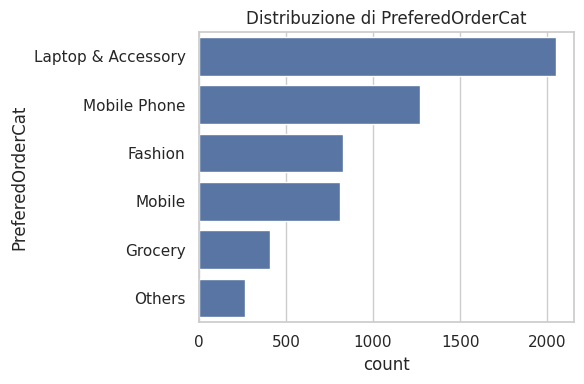

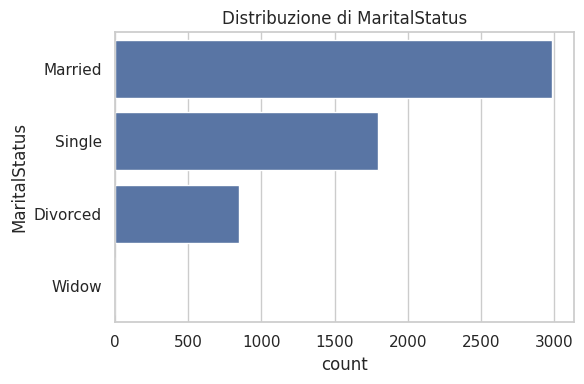

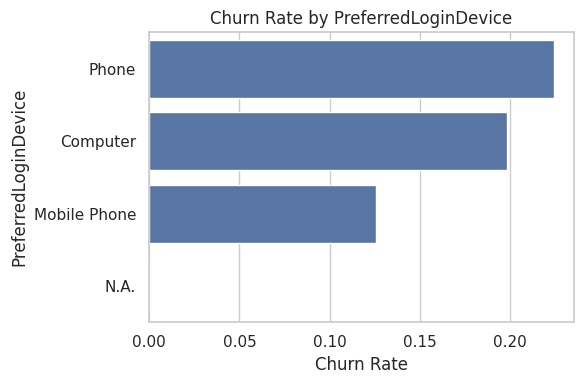

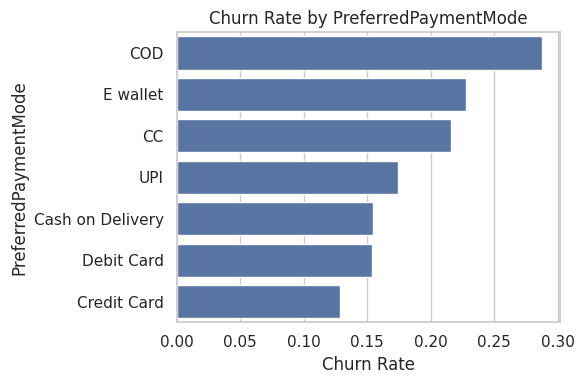

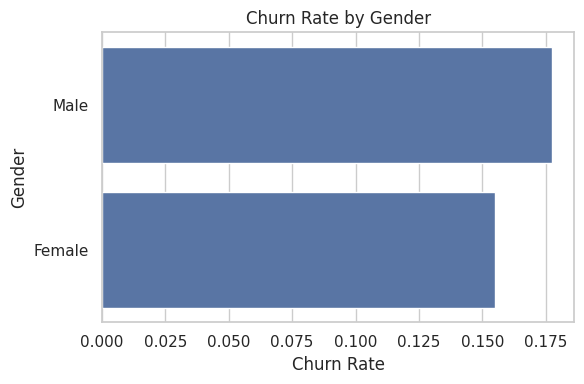

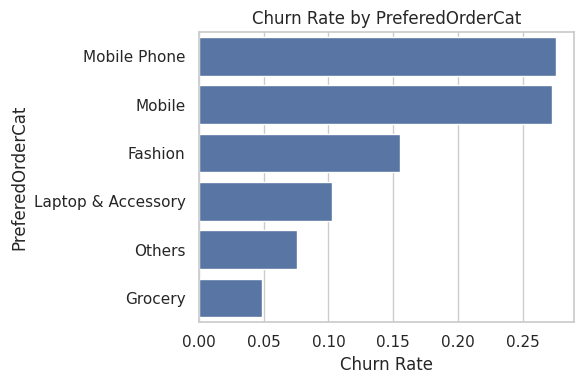

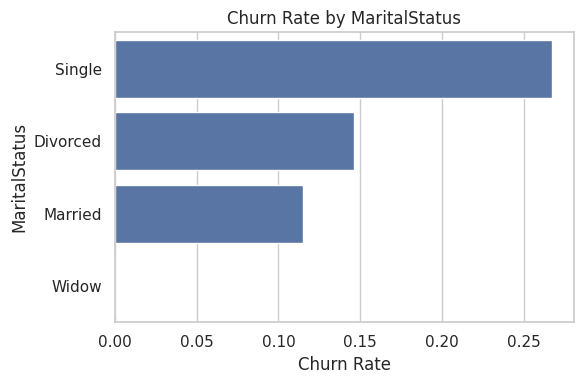

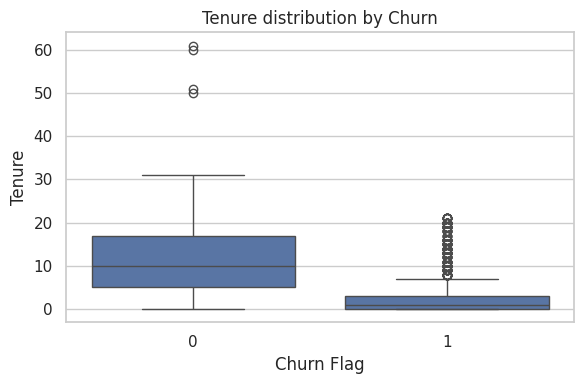

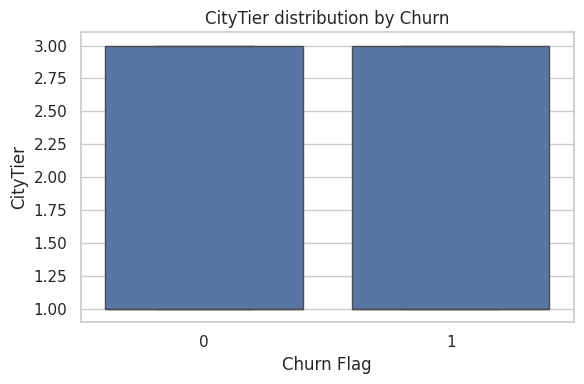

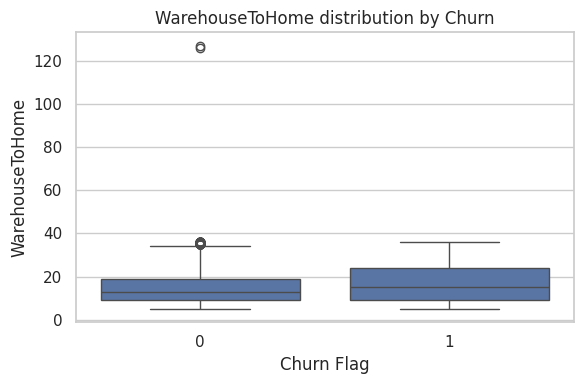

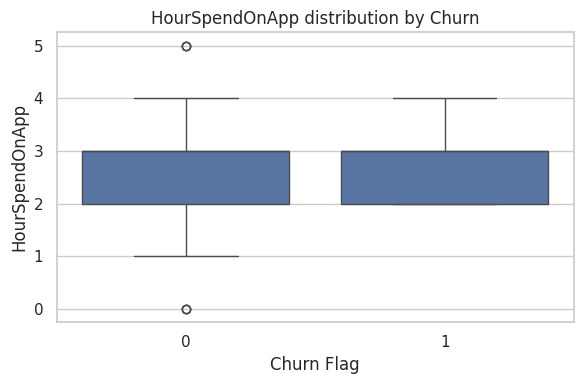

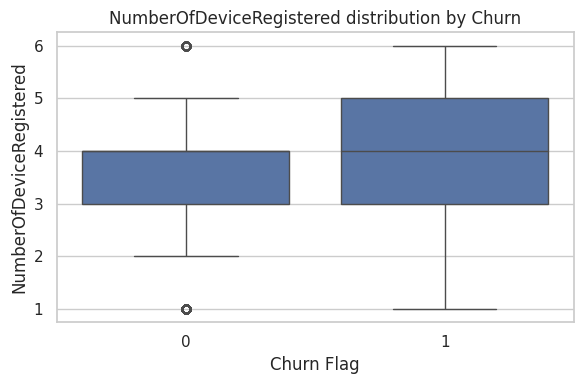

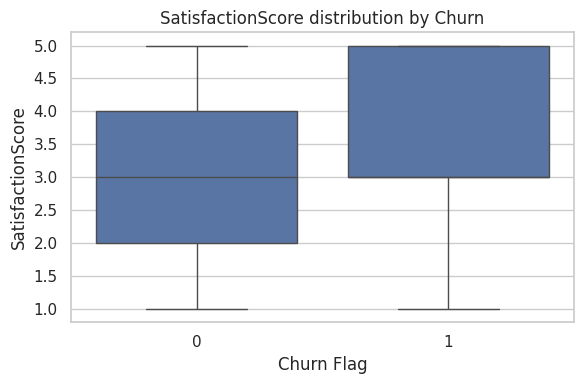

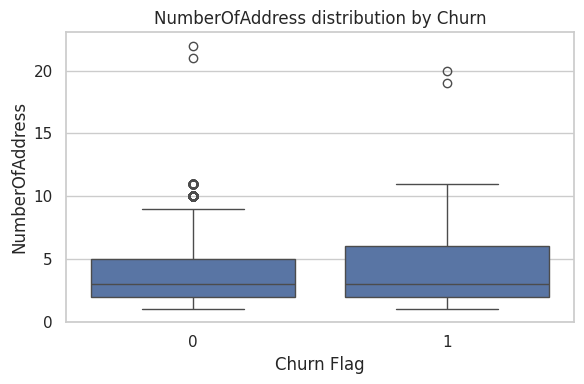

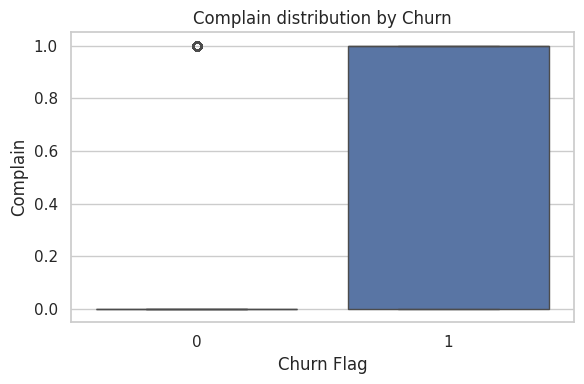

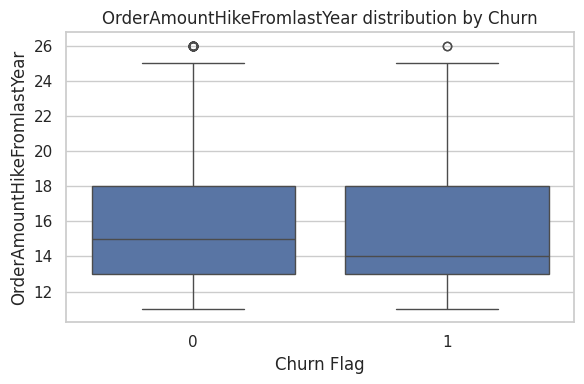

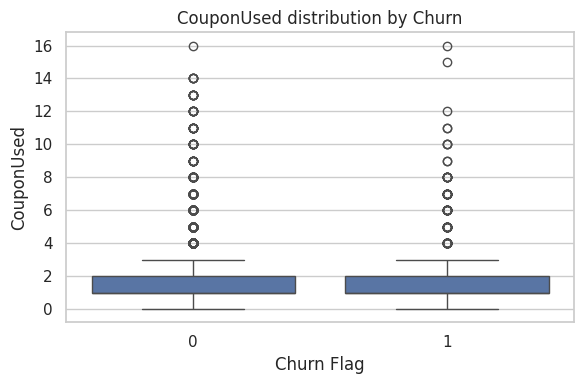

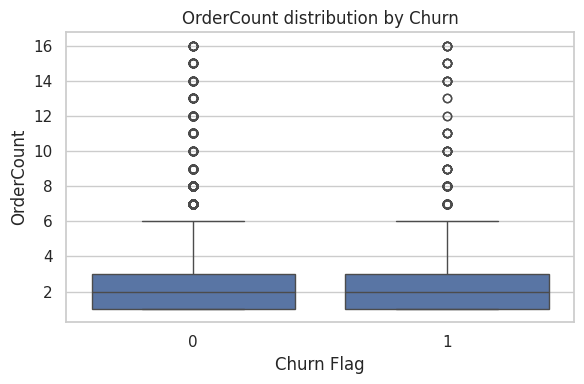

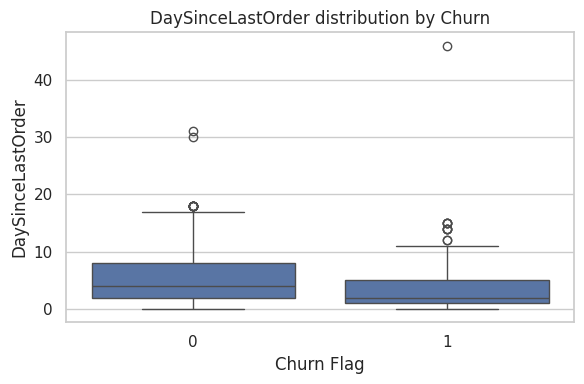

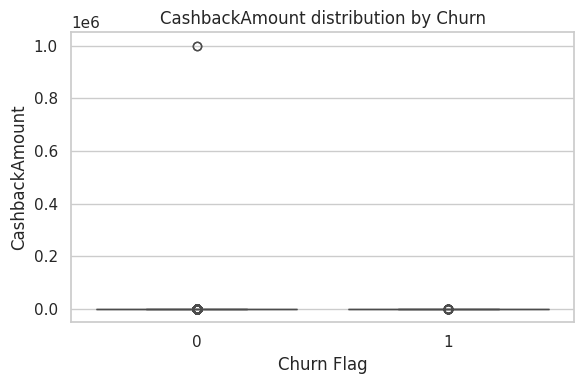

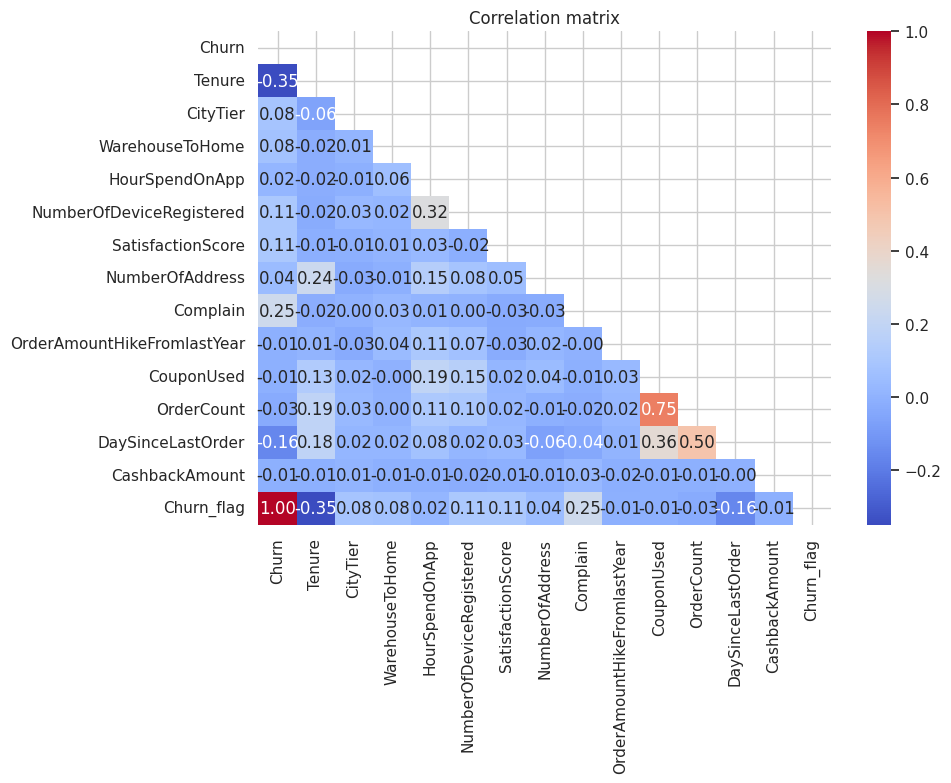

In [20]:
# Visualizzazione dei valori mancanti
plt.figure(figsize=(8,4))
msno.bar(df)
plt.title('Missing values bar chart')
plt.show()

plt.figure(figsize=(8,6))
msno.heatmap(df)
plt.title('Missing values correlation matrix')
plt.show()

# Tabella riepilogativa dei missing
missing = df.isnull().sum()
missing = missing[missing > 0]
pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'missing_count': missing, 'missing_pct': pct}))

# Distribuzioni univariate
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Rimuove l'ID se presente nelle numeriche
if 'CustomerID' in num_cols:
    num_cols.remove('CustomerID')

# Distribuzioni delle variabili numeriche
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribuzione di {col}')
    plt.tight_layout()
    plt.show()

# Distribuzioni delle variabili categoriche
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribuzione di {col}')
    plt.tight_layout()
    plt.show()

# Analisi bivariata rispetto al Churn
if 'Churn' in df.columns:
    df['Churn_flag'] = df['Churn']

    # Tasso di churn per ciascuna categoria
    for col in cat_cols:
        plt.figure(figsize=(6,4))
        prop = df.groupby(col)['Churn_flag'].mean().sort_values(ascending=False)
        sns.barplot(x=prop.values, y=prop.index)
        plt.xlabel('Churn Rate')
        plt.title(f'Churn Rate by {col}')
        plt.tight_layout()
        plt.show()

    # Boxplot delle variabili numeriche per churn
    numeric_for_bivariate = [col for col in num_cols if col != 'Churn']
    for col in numeric_for_bivariate:
        plt.figure(figsize=(6,4))
        sns.boxplot(x='Churn_flag', y=col, data=df)
        plt.xlabel('Churn Flag')
        plt.title(f'{col} distribution by Churn')
        plt.tight_layout()
        plt.show()

# Matrice di correlazione
corr_cols = num_cols + (['Churn_flag'] if 'Churn_flag' in df.columns else [])
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10,8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

# Rimozione colonna di supporto
df.drop(columns=['Churn_flag'], errors='ignore', inplace=True)


**3. Data Cleaning & Feature Engineering**

In [28]:
# Copia di sicurezza del dataset
df_clean = df.copy()

# Rimozione dell'ID cliente
if 'CustomerID' in df_clean.columns:
    df_clean.drop(columns='CustomerID', inplace=True)

# Separazione delle variabili indipendenti (X) dalla variabile target (y)
y = df_clean['Churn']
X = df_clean.drop(columns='Churn')

# Gestione dei valori mancanti

# Imputazione mediana per numeriche
num_features = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'OrderAmountHikeFromlastYear', 'OrderCount', 'DaySinceLastOrder']
for col in num_features:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)

# Imputazione moda per categoriche
cat_features = ['Gender', 'CouponUsed']
for col in cat_features:
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)

# Rimuoviamo l'outlier estremo dalla colonna 'CashbackAmount'
df = df[df['CashbackAmount'] != 999999]


# Rimozione delle variabili ritenute poco informative (da EDA)
features_to_drop = ['Gender', 'OrderCount', 'CashbackAmount', 'CouponUsed',
                    'CityTier', 'HourSpendOnApp']
df_clean.drop(columns=features_to_drop, inplace=True)


# Encoding delle variabili categoriche rimaste
X_encoded = pd.get_dummies(df_clean.drop(columns='Churn'), drop_first=True)



/tmp/ipython-input-28-2476629015.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_val, inplace=True)
/tmp/ipython-input-28-2476629015.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [29]:

print("Nuova shape:", df_clean.shape)

Nuova shape: (5628, 13)


**4. Train-Test Split**

In [26]:
# Divisione del dataset in training e test set
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, df_clean['Churn'],
    test_size=0.2,
    stratify=df_clean['Churn'],
    random_state=42
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 4504, Test size: 1126


**5. Model Training**

In [27]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Griglia di iperparametri
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Modello base
xgb_clf = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# GridSearch con 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

# Esecuzione del tuning
grid_search.fit(X_train, y_train)

# Miglior modello
best_model = grid_search.best_estimator_

# Stampa dei migliori parametri
print("Migliori iperparametri trovati:")
print(grid_search.best_params_)


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Migliori iperparametri trovati:
{'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:17:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


**6. Model Evaluation**

ROC AUC: 0.991
Accuracy: 0.965
Recall: 0.853
Precision: 0.936


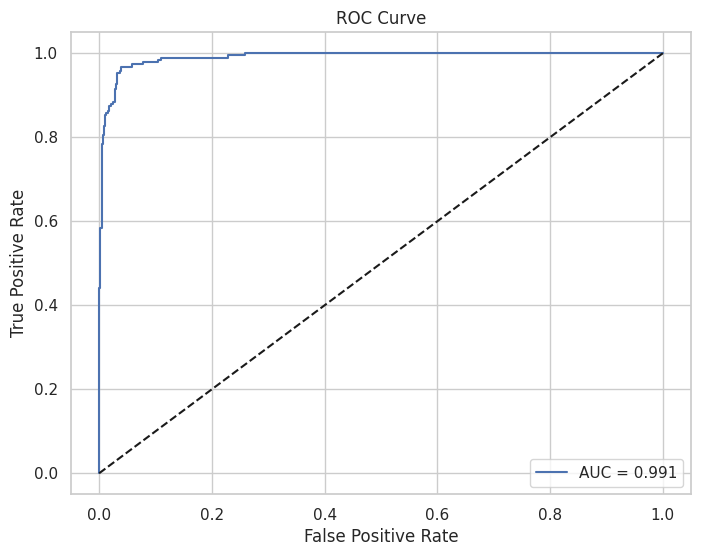

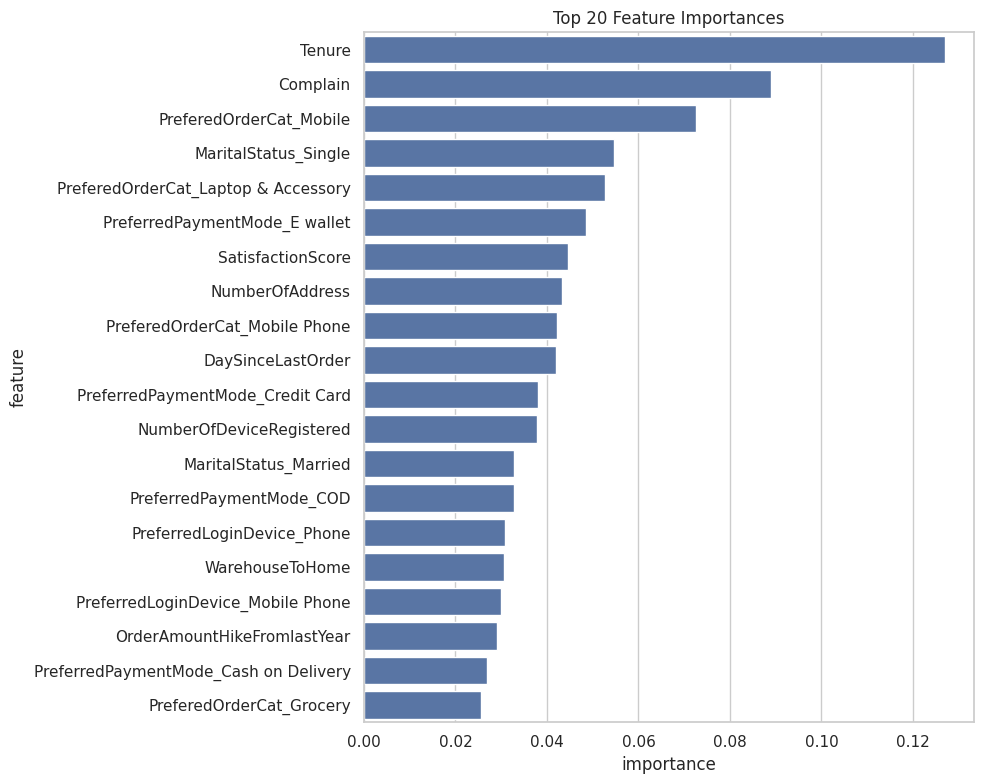

In [24]:
# Predizioni sul test set
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

# Metriche di valutazione
auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"ROC AUC: {auc:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Recall: {recall:.3f}")
print(f"Precision: {precision:.3f}")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Feature Importance dal miglior modello
importances = best_model.feature_importances_
imp_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
imp_df.sort_values(by='importance', ascending=False, inplace=True)

plt.figure(figsize=(10,8))
sns.barplot(x='importance', y='feature', data=imp_df.head(20))
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

